# AI Readiness Observatory

Explore the mart models built with dbt.

In [1]:
import duckdb
import pandas as pd # pyright: ignore[reportMissingModuleSource]
import matplotlib.pyplot as plt

con = duckdb.connect('../data/ai_readiness.duckdb')

## Preview fact table

In [2]:
df = con.sql('SELECT * FROM fct_country_ai_readiness limit 10').df()
df.head()

,country_code,year,unemployment_rate,gdp_per_capita,ai_readiness_index
0,ABW,1986,NaN,6767.559082,NaN
1,ABW,1987,NaN,8244.045898,NaN
2,ABW,1988,NaN,10056.261719,NaN
3,ABW,1989,NaN,11507.216797,NaN
4,ABW,1990,NaN,12187.536133,NaN


## Average AI Readiness Score

In [4]:
con.sql('''
SELECT ROUND(AVG(ai_readiness_index),2) AS average_ai_readiness_index
FROM fct_country_ai_readiness
''').df()

,average_ai_readiness_index
0,45.13


## Countries by AI Readiness Category

In [9]:
category = con.sql('''
SELECT ai_readiness_category, COUNT(*) AS countries
FROM fct_country_ai_readiness
GROUP BY 1
ORDER BY 1
''').df()
category

,ai_readiness_category,countries
0,High,2
1,Low,234
2,Medium,86
3,No Data,14480


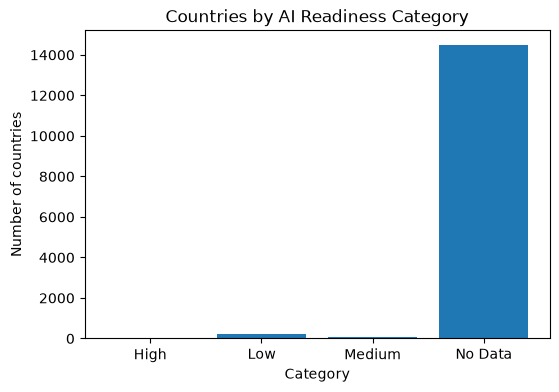

In [10]:
plt.figure(figsize=(6,4))
plt.bar(category["ai_readiness_category"], category["countries"])
plt.title("Countries by AI Readiness Category")
plt.xlabel("Category")
plt.ylabel("Number of countries")
plt.show()

## Top 10 Countries

In [13]:
top10 = con.sql('''
SELECT c.country_name, f.ai_readiness_score
FROM fct_country_ai_readiness f
JOIN dim_country c ON f.country_code_iso3=c.country_code_iso3
ORDER BY ai_readiness_score DESC
LIMIT 10
''').df()
top10

,country_name,ai_readiness_score
0,singapore,84.249441
1,france,80.810000
2,france,79.357543
3,canada,78.175297
4,netherlands,77.229804
5,netherlands,77.180000
6,germany,76.898268
7,germany,76.780000
8,finland,76.484718
9,australia,76.447268


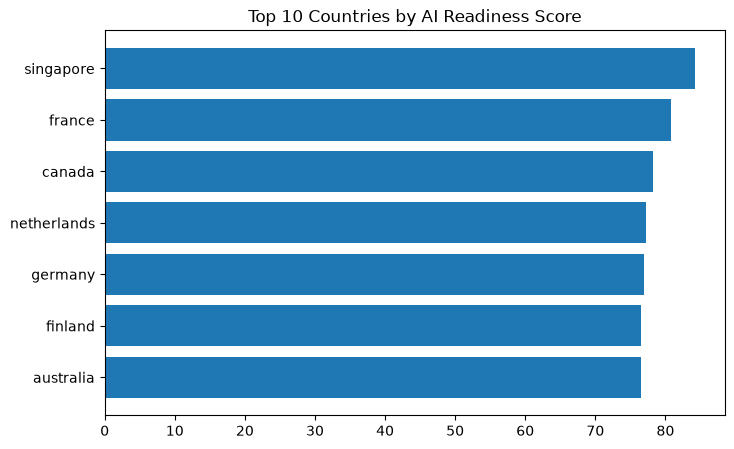

In [15]:
plt.figure(figsize=(8,5))
plt.barh(top10["country_name"], top10["ai_readiness_score"])
plt.gca().invert_yaxis()
plt.title("Top 10 Countries by AI Readiness Score")
plt.show()

## Unemployment Rate vs AI Readiness

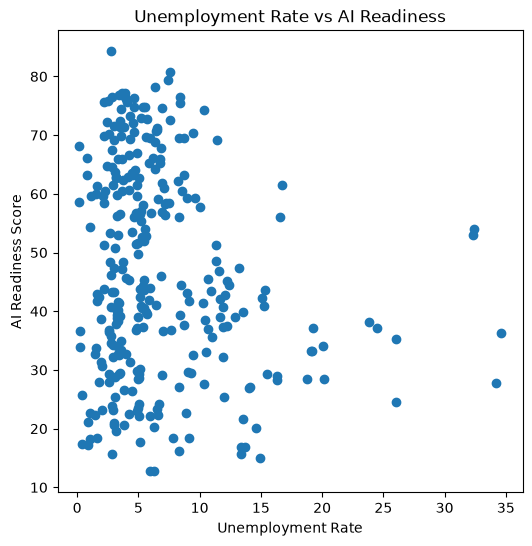

In [18]:
scatter = con.sql('''
SELECT unemployment_rate, ai_readiness_score
FROM fct_country_ai_readiness
''').df()

plt.figure(figsize=(6,6))
plt.scatter(scatter["unemployment_rate"], scatter["ai_readiness_score"])
plt.xlabel("Unemployment Rate")
plt.ylabel("AI Readiness Score")
plt.title("Unemployment Rate vs AI Readiness")
plt.show()

## Semantic Layer

The notebook queries the fact table directly. The same business metrics are also defined in the dbt Semantic Layer, allowing BI tools to reuse governed metric definitions.